### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation_MOD as sim
import sys
sys.path.insert(0, './param_import/')
from imports import *
import parameters as pm


In [3]:
pm.show_parameters()
print()
fname = pm.my_name()  # <-- ALTER THIS
print("File with final alpha parameters will be '{}'".format(fname))


Block: 1551055211
Frequency range: 1100 - 1350 MHz
Time range: 5500 - 6200 seconds
The cost function denominator will be: unweighted (C2).
Masking: Temporal (shown above)

File with final alpha parameters will be 'results/individual_sats0/interval5500-6200_C2.p'


### 2. Setting up the simulation

We initialize the SatelliteSimulation object, which will store the information. 

Getting catalog...
Number of signals in satellite catalog:  286
Getting beam response...
Number of satellites present:  73
Starting index of satellites:  [  0   4   8  12  16  20  24  28  32  36  40  44  48  52  56  60  64  68
  72  76  80  84  88  92  96 100 104 108 112 114 116 118 120 122 123 124
 125 126 127 128 129 130 131 136 141 146 151 156 161 166 171 176 181 186
 191 196 201 206 211 216 221 226 231 236 241 246 251 256 261 266 271 276
 281]


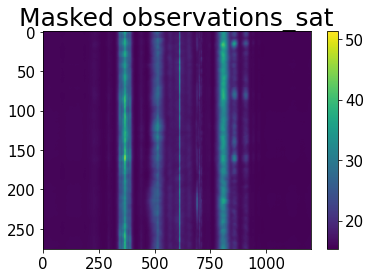

Size of arrays:
 - Frequency:  (1199,)
 - Time:  (276,)
 - Size of simulated Tb_factors:  (286, 1199)
 - Size of simulated sat_beam:  (73, 1199, 276)
 - Size of observations:  (1199, 276)


In [4]:
# initializing the function
sat = sim.SatelliteSimulation(
    block=str(pm.block),
    use_data=True,
    path_data=pm.path_data,
    path_beam=pm.path_data,
    survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency],
    path_catalog=pm.path_catalog,
    beam_model=pm.beam_model,
    freq_range=[pm.fs, pm.fe],
    freq_slice=[pm.fs_slice, pm.fe_slice],
    time_slice=[pm.ts_slice, pm.te_slice],
    include_cons=pm.include_cons,
    verbose=True,
)

# applying mask
sat.create_mask(pm.path_nearby, pm.mask_temperature, pm.mask_pix, verbose=True)


In [5]:
# choosing which function to use
if pm.CF_case == "C1":  CF = sim.CF_radiometer
elif pm.CF_case == "C2":  CF = sim.CF_unweighted

# creating array of indexes necessary to broadcast (only need to compute it once)
sizes = np.diff(np.hstack([sat.index_sats, 286]))
index_alphas = []
n = 0
for i in range(len(sat.cons)):
    if (i!=0) and (sat.cons[i]!=sat.cons[i-1]):  n += sizes[i-1]
    index_alphas.extend(n + np.arange(sizes[i]))
order = np.array([0,1,2,3,9,10,11,12,18,19,20,4,5,6,7,8,13,14,15,16,17])  # <-- get the same order as before!

# auxiliary function that simulates the original set-up
def CF_reduced(alphas_reduced,sat):
    ''' Computes CF for the given alphas, using the original formulation (fitting signals of each
    constellation) but with the new code (fitting signals of each satellite). '''

    # running usual code
    result = CF(alphas_reduced[order][index_alphas],sat)
    #print(result," with ",alphas_reduced,end="\n\n")
    print(result,end="\t")
    return result


In [6]:
# defining initial values and boundary conditions
#alphas0 = np.zeros(len(sat.catalog))
#bnds = [(0.0,None) for _ in range(len(sat.catalog))]
alphas0 = np.zeros(21)
bnds = [(0.0,None) for _ in range(21)]

# testing cost function at initial value
_ = CF_reduced(alphas0,sat)


6976740.588681895	

### 3. Running the optimization

We now run the optimization with the functions and parameters defined above.

In [7]:
# running the optimization
print("Running optimization...")
start = time.perf_counter()
signal_PL = opt.minimize(
    fun = CF_reduced,
    x0 = alphas0,
    args = (sat,),
    method = "Powell",
    bounds = bnds,
    tol = 1e-6,
    options={"maxiter":30, "disp":True},
)

elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Running optimization...
6976740.588681895	6900137.511317555	6828774.452373715	6755845.346927684	6710153.580923876	6804812.777788489	6719541.344179909	6715832.751548969	6710193.313345038	6710004.839774635	6710613.039638024	6709996.4523789035	6709996.199527232	6709996.196418373	6709996.196409325	6709996.196409956	6709996.196410121	6615681.937040223	6831428.10095705	6623771.869889421	6613220.334091023	6612885.748627346	6612872.414951566	6612871.6131468015	6612871.607593627	6612871.607587464	6612871.6075875	6612871.607587552	6705891.107073347	7839253.1722605135	6561926.498836404	6573141.597826211	6550081.55655607	6554206.552385745	6548487.878726951	6548484.80335415	6548484.244719346	6548484.243922005	6548484.243921851	6548484.243921967	5196252.517675677	21200630.537930124	4007980.145649312	4079236.947397537	4003701.7576956516	4003363.0204441138	4003361.262174559	4003361.2511162655	4003361.2511107917	4003361.2511132383	3976064.1709783906	3965472.4589914954	3988034.2093386212	3967162.9863570

Catalog updated with alphas!


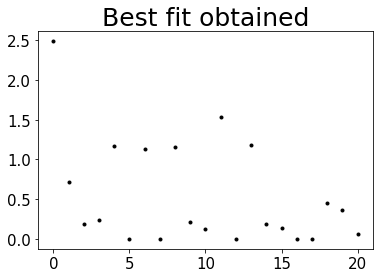

In [8]:
# saving best fit values
alphas_best_fit = signal_PL.x
sat.update_alphas(alphas_best_fit[order][index_alphas])

# plotting values
plt.plot(alphas_best_fit,"k.")
plt.title("Best fit obtained")
plt.show()

In [9]:
# saving information in the file
data_info = {
    "initial" : alphas0,
    "time" : [pm.ts_slice, pm.te_slice],
    "frequency_slice" : [pm.fs_slice, pm.fe_slice],
    "best-fit" : alphas_best_fit,
    "chi2_value" : signal_PL.fun,
    "chi2_div" : signal_PL.fun / sat.simulation.size,
}

print(f"Information saved in file '{fname}'.")
pickle.dump( data_info, open(fname,"wb") )

Information saved in file 'results/individual_sats0/interval5500-6200_C2.p'.
